In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import gc
sns.set_theme()
gc.enable()

In [2]:
main_data=pd.read_csv('application_train.csv')
main_data.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
numerical_features=main_data.select_dtypes(exclude='object').columns
encoded_features=pd.Index(['FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE',
                           'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL',
                           'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION',
                           'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY',
                           'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY',
                           'FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_3', 'FLAG_DOCUMENT_4',
                           'FLAG_DOCUMENT_5', 'FLAG_DOCUMENT_6', 'FLAG_DOCUMENT_7',
                           'FLAG_DOCUMENT_8', 'FLAG_DOCUMENT_9', 'FLAG_DOCUMENT_10',
                           'FLAG_DOCUMENT_11', 'FLAG_DOCUMENT_12', 'FLAG_DOCUMENT_13',
                           'FLAG_DOCUMENT_14', 'FLAG_DOCUMENT_15', 'FLAG_DOCUMENT_16',
                           'FLAG_DOCUMENT_17', 'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19',
                           'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_21'])
categorical_features=main_data.columns.difference(numerical_features)
numerical_features=numerical_features.difference(encoded_features)

# Numerical Features

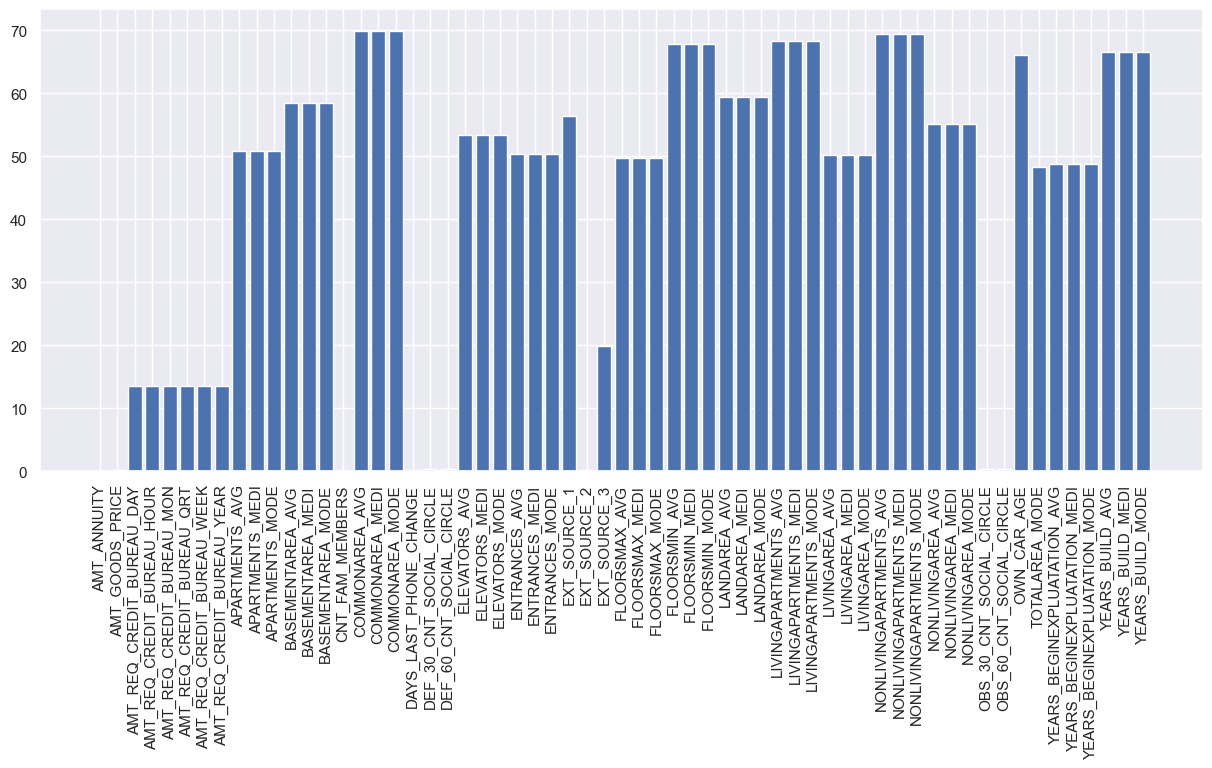

In [4]:
numerical_frame=main_data.loc[:, numerical_features]
plot_data=numerical_frame.isnull().sum()*100/numerical_frame.shape[0]
plot_data=plot_data[plot_data>0]
ax=plt.axes()
ax.bar(plot_data.index, plot_data.values)
ax.tick_params(axis='x', rotation=90)
ax.get_figure().set_size_inches(15, 6)

### Functions

In [5]:
def plot_hist_box(data, feature):
    fig, axes=plt.subplots(ncols=2)
    fig.set_size_inches(w=10, h=5)
    axes[0].boxplot(data[feature].dropna());
    axes[0].set_xticklabels([feature]);
    axes[1].hist(data[feature]);

In [6]:
def plot_hist_default_pct(feature, dataframe, bins):
    df=dataframe.copy()
    df['%s_binned'%feature]=pd.qcut(df[feature], q=bins, precision=3, duplicates='drop')
    counts=df['%s_binned'%feature].value_counts()
    default_counts=df.loc[df['TARGET']==1, '%s_binned'%feature].value_counts()
    default_counts=default_counts*100/counts
    ax=plt.axes()
    ax.bar(default_counts.index.astype(str), default_counts.values)
    ax.tick_params(axis='x', rotation=90)
    ax.set_title('Deafulters %% in %s'%feature)
    ax.set_xlabel('Category')
    ax.set_ylabel('Defaulter %')
    print(default_counts)


In [7]:
def plot_kde_vs_target(feature, main_data=main_data):
    paid=main_data[main_data['TARGET']==0][feature]
    defaulted=main_data[main_data['TARGET']==1][feature]
    sns.kdeplot(paid, label='Paid', color='b')
    sns.kdeplot(defaulted, label='Defaulted', color='r')
    plt.legend()

def plot_all_numeric_kde():
    fig, axes=plt.subplots(numerical_features.shape[0])
    fig.set_size_inches(10, 4*numerical_features.shape[0])
    for i, feature in enumerate(numerical_features):
        paid=main_data[main_data['TARGET']==0][feature]
        defaulted=main_data[main_data['TARGET']==1][feature]
        sns.kdeplot(paid, label='Paid', color='b', ax=axes[i])
        sns.kdeplot(defaulted, label='Defaulted', color='r', ax=axes[i])
        axes[i].legend()

In [8]:
def plot_pie_target(target_series, ax=None):
    if ax is None:
        ax=plt.axes()
    plot_data=target_series.value_counts()
    plot_data.rename(index={0: "Paid", 1: "Defaulted"}, inplace=True)
    ax.pie(x=plot_data.values, labels=plot_data.index, autopct='%1.1f%%')
    return ax

In [9]:
# plot_all_numeric_kde()

### Important Numerical

In [10]:
important_kde=pd.Index(['AMT_ANNUITY', 'AMT_CREDIT', 'DAYS_BIRTH',
                        'DAYS_EMPLOYED', 'DAYS_ID_PUBLISH', 'DAYS_REGISTRATION',
                        'DAYS_LAST_PHONE_CHANGE', 'EXT_SOURCE_1', 'EXT_SOURCE_2',
                        'EXT_SOURCE_3'])
numerical_frame=numerical_frame[important_kde]
numerical_frame['TARGET']=main_data['TARGET']

In [11]:
numerical_frame.isnull().sum()

AMT_ANNUITY                   12
AMT_CREDIT                     0
DAYS_BIRTH                     0
DAYS_EMPLOYED                  0
DAYS_ID_PUBLISH                0
DAYS_REGISTRATION              0
DAYS_LAST_PHONE_CHANGE         1
EXT_SOURCE_1              173378
EXT_SOURCE_2                 660
EXT_SOURCE_3               60965
TARGET                         0
dtype: int64

## AMT_CREDIT

In [12]:
numerical_frame['AMT_CREDIT'].isnull().sum()

0

In [13]:
numerical_frame['AMT_CREDIT'].describe()

count    3.075110e+05
mean     5.990260e+05
std      4.024908e+05
min      4.500000e+04
25%      2.700000e+05
50%      5.135310e+05
75%      8.086500e+05
max      4.050000e+06
Name: AMT_CREDIT, dtype: float64

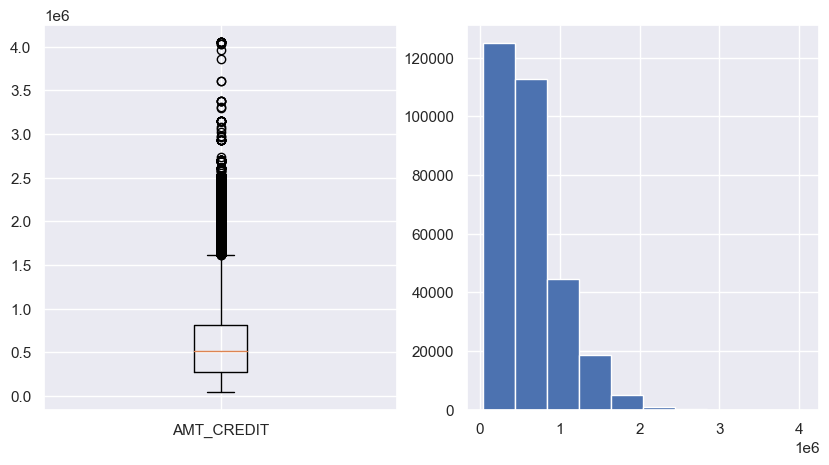

In [14]:
plot_hist_box(numerical_frame, 'AMT_CREDIT')

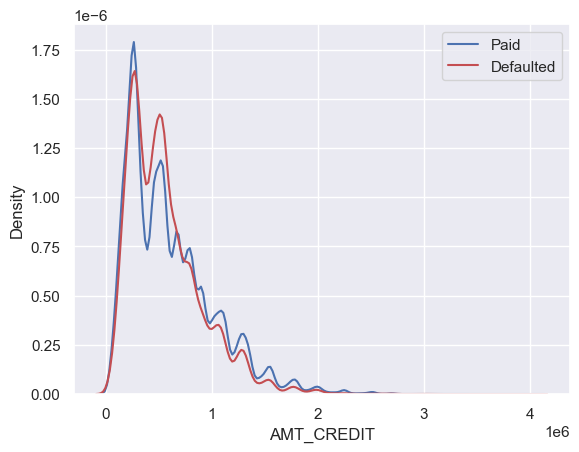

In [15]:
plot_kde_vs_target('AMT_CREDIT', numerical_frame)

(44999.999, 225000.0]      7.097365
(225000.0, 292500.0]       7.945478
(292500.0, 450000.0]      10.315083
(450000.0, 568197.0]       9.594215
(568197.0, 760225.5]       8.781786
(760225.5, 1042560.0]      7.161912
(1042560.0, 4050000.0]     5.689806
Name: AMT_CREDIT_binned, dtype: float64


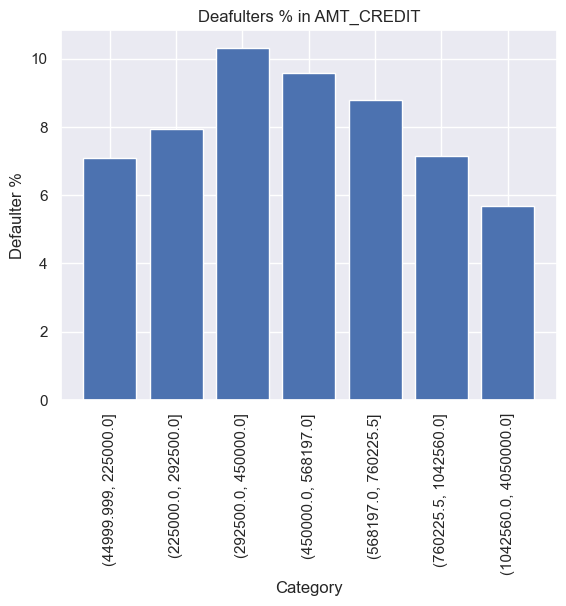

In [16]:
plot_hist_default_pct('AMT_CREDIT', numerical_frame, 7)

## DAYS_BIRTH

In [17]:
numerical_frame['DAYS_BIRTH'].isnull().sum()

0

In [18]:
numerical_frame['DAYS_BIRTH'].describe()

count    307511.000000
mean     -16036.995067
std        4363.988632
min      -25229.000000
25%      -19682.000000
50%      -15750.000000
75%      -12413.000000
max       -7489.000000
Name: DAYS_BIRTH, dtype: float64

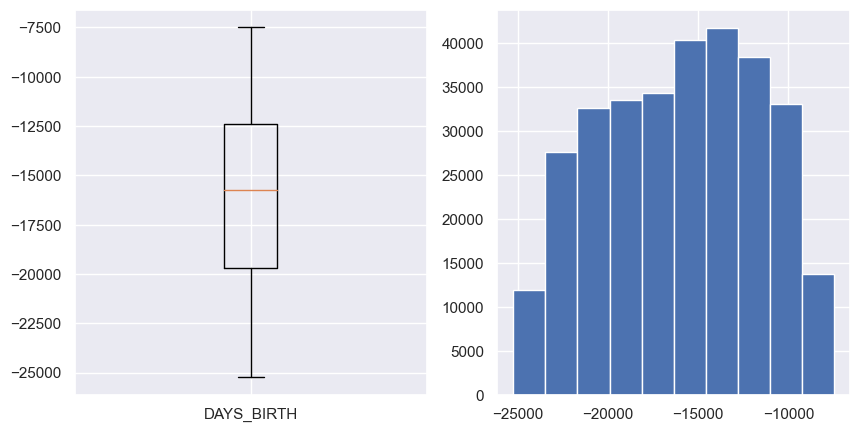

In [19]:
plot_hist_box(numerical_frame, 'DAYS_BIRTH')

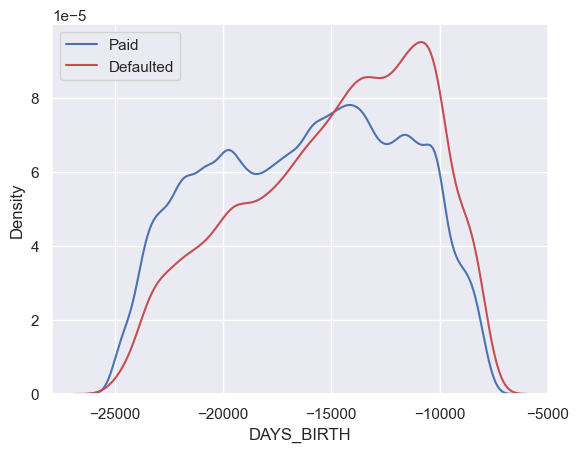

In [20]:
plot_kde_vs_target('DAYS_BIRTH', numerical_frame)

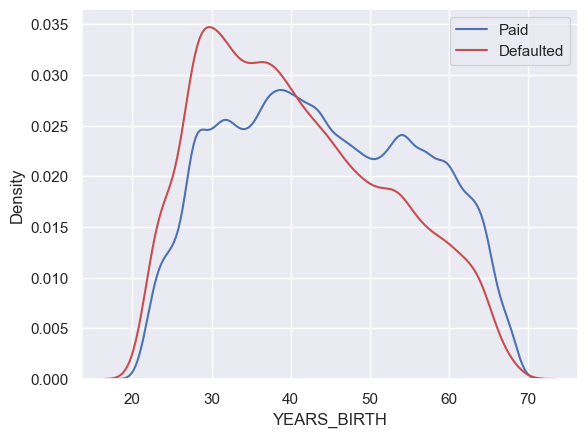

In [21]:
numerical_frame['YEARS_BIRTH']=numerical_frame['DAYS_BIRTH']/-365
plot_kde_vs_target('YEARS_BIRTH', numerical_frame)

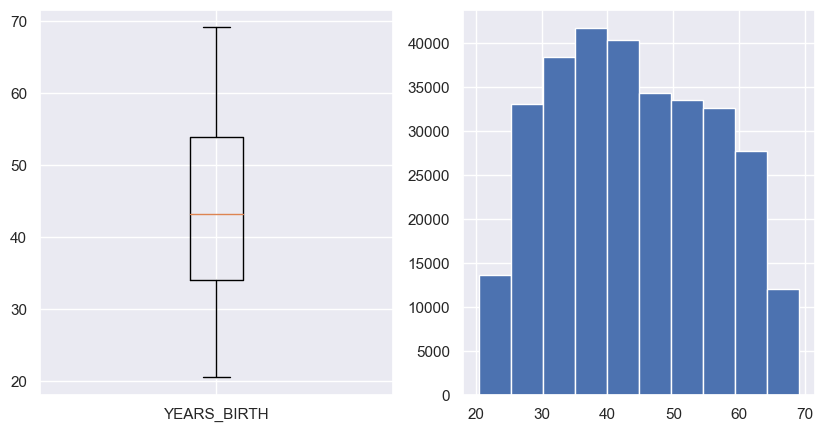

In [22]:
plot_hist_box(numerical_frame, 'YEARS_BIRTH')

(20.517, 28.594]    11.537111
(28.594, 32.899]    10.686487
(32.899, 37.195]     9.724336
(37.195, 41.09]      8.406976
(41.09, 45.31]       7.802664
(45.31, 50.173]      7.422469
(50.173, 55.047]     6.633489
(55.047, 60.225]     5.478971
(60.225, 69.121]     4.961799
Name: YEARS_BIRTH_binned, dtype: float64


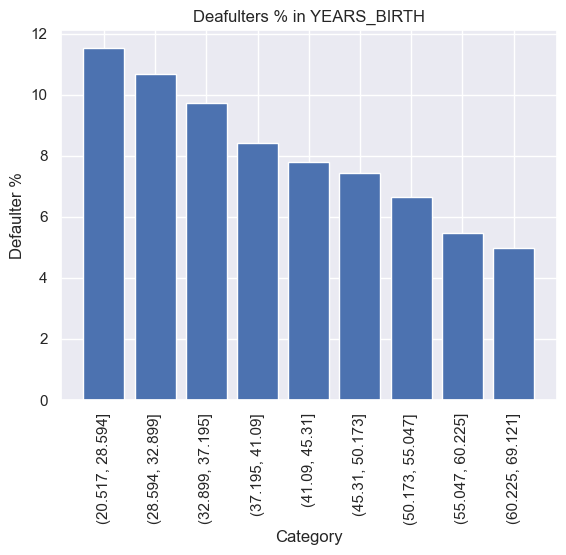

In [23]:
plot_hist_default_pct('YEARS_BIRTH', numerical_frame, 9)

## DAYS_ID_PUBLISH

In [ ]:
numerical_frame['DAYS_ID_PUBLISH'].isnull().sum()

0

In [ ]:
numerical_frame['DAYS_ID_PUBLISH'].describe()

count    307511.000000
mean      -2994.202373
std        1509.450419
min       -7197.000000
25%       -4299.000000
50%       -3254.000000
75%       -1720.000000
max           0.000000
Name: DAYS_ID_PUBLISH, dtype: float64

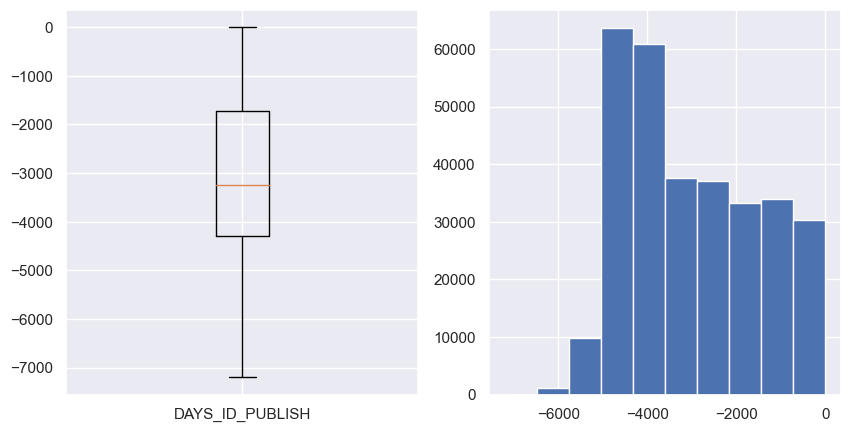

In [ ]:
plot_hist_box(numerical_frame, 'DAYS_ID_PUBLISH')

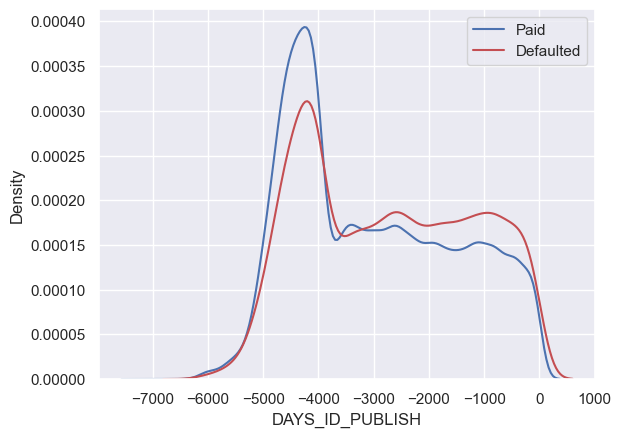

In [ ]:

plot_kde_vs_target('DAYS_ID_PUBLISH', numerical_frame)

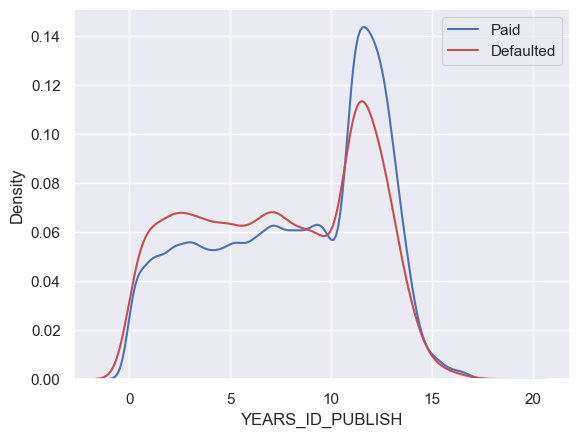

In [ ]:
numerical_frame['YEARS_ID_PUBLISH']=numerical_frame['DAYS_ID_PUBLISH']/-365
plot_kde_vs_target('YEARS_ID_PUBLISH', numerical_frame)

(-0.001, 2.192]     10.169541
(2.192, 4.192]       9.734176
(4.192, 6.197]       9.210642
(6.197, 8.0]         8.753588
(8.0, 9.789]         7.963488
(9.789, 11.205]      7.880824
(11.205, 11.978]     6.769168
(11.978, 12.833]     6.095099
(12.833, 19.718]     6.074712
Name: YEARS_ID_PUBLISH_binned, dtype: float64


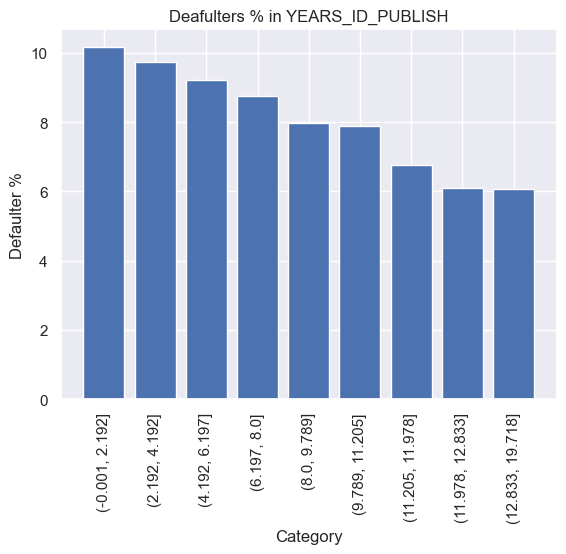

In [ ]:
plot_hist_default_pct('YEARS_ID_PUBLISH', numerical_frame, 9)

## DAYS_REGISTRATION

In [ ]:
numerical_frame['DAYS_REGISTRATION'].isnull().sum()

0

In [ ]:
numerical_frame['DAYS_REGISTRATION'].describe()

count    307511.000000
mean      -4986.120328
std        3522.886321
min      -24672.000000
25%       -7479.500000
50%       -4504.000000
75%       -2010.000000
max           0.000000
Name: DAYS_REGISTRATION, dtype: float64

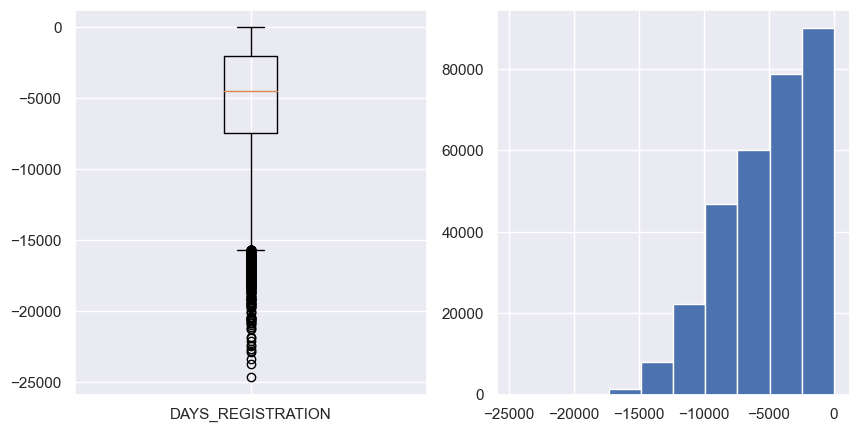

In [ ]:
plot_hist_box(numerical_frame, 'DAYS_REGISTRATION')

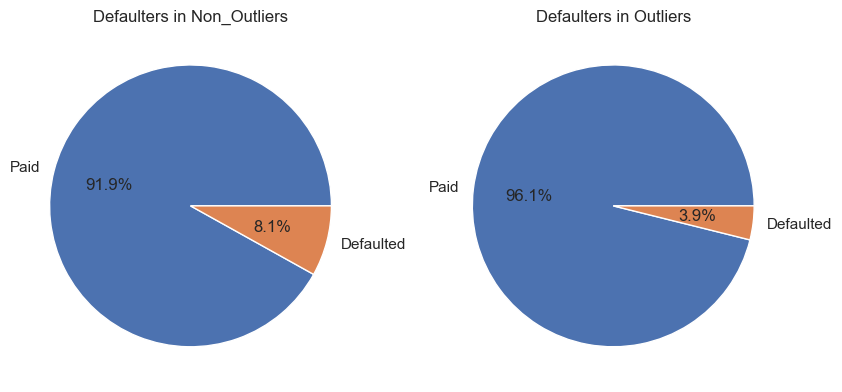

In [ ]:
fig, axes=plt.subplots(ncols=2)
fig.set_size_inches(w=10, h=5)
plot_pie_target(numerical_frame.loc[numerical_frame['DAYS_REGISTRATION']<-15500, 'TARGET'], ax=axes[1])
axes[1].set_title("Defaulters in Outliers");
plot_pie_target(numerical_frame.loc[numerical_frame['DAYS_REGISTRATION']>=-15500, 'TARGET'], ax=axes[0])
axes[0].set_title("Defaulters in Non_Outliers");


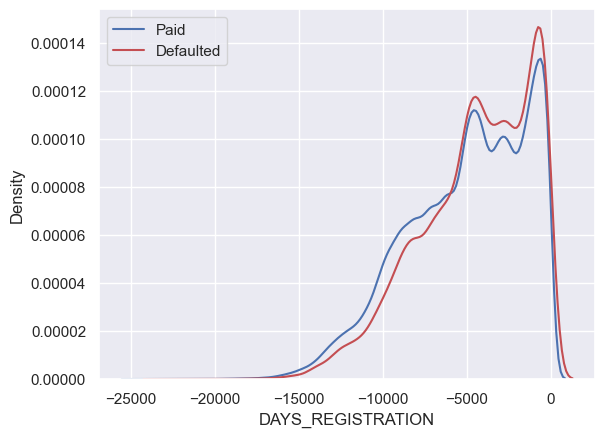

In [ ]:
plot_kde_vs_target('DAYS_REGISTRATION', numerical_frame)

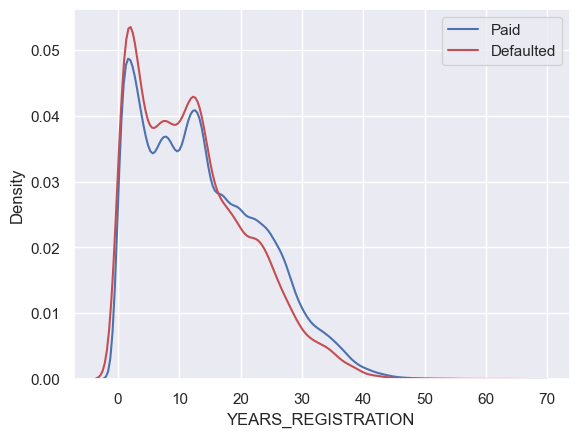

In [ ]:
numerical_frame['YEARS_REGISTRATION']=numerical_frame['DAYS_REGISTRATION']/-365
plot_kde_vs_target('YEARS_REGISTRATION', numerical_frame)

(-0.001, 2.107]     9.656947
(2.107, 4.699]      8.869056
(4.699, 7.838]      8.647509
(7.838, 10.981]     8.742834
(10.981, 13.671]    8.639265
(13.671, 17.31]     8.196721
(17.31, 21.66]      7.338483
(21.66, 26.616]     6.897662
(26.616, 67.595]    5.665681
Name: YEARS_REGISTRATION_binned, dtype: float64


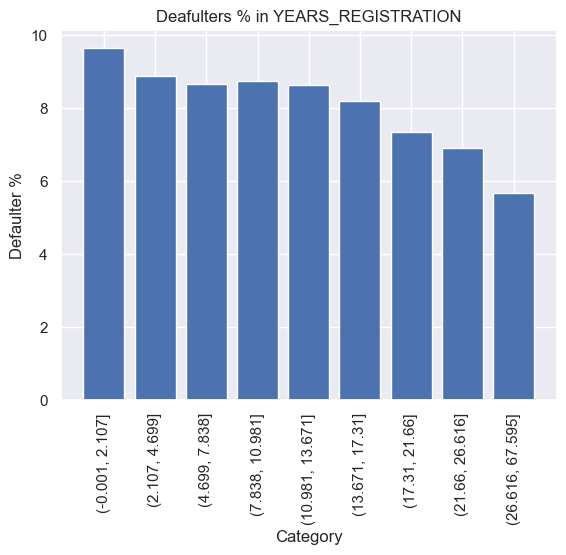

In [ ]:
plot_hist_default_pct('YEARS_REGISTRATION', numerical_frame, 9)

## DAYS_EMPLOYED

In [24]:
numerical_frame['DAYS_EMPLOYED'].isnull().sum()

0

In [25]:
numerical_frame['DAYS_EMPLOYED'].describe()

count    307511.000000
mean      63815.045904
std      141275.766519
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64

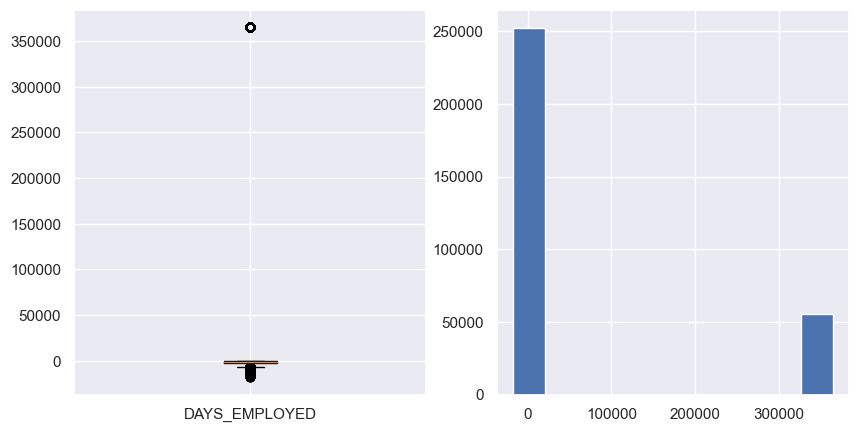

In [26]:
plot_hist_box(numerical_frame, 'DAYS_EMPLOYED')

In [27]:
numerical_frame.loc[numerical_frame['DAYS_EMPLOYED']>0, ['DAYS_EMPLOYED', 'TARGET']].value_counts()

DAYS_EMPLOYED  TARGET
365243         0         52384
               1          2990
dtype: int64

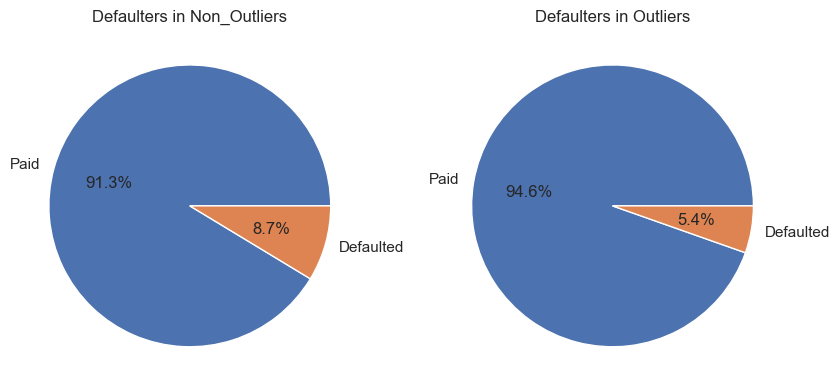

In [28]:
fig, axes=plt.subplots(ncols=2)
fig.set_size_inches(w=10, h=5)
plot_pie_target(numerical_frame.loc[numerical_frame['DAYS_EMPLOYED']>0, 'TARGET'], ax=axes[1])
axes[1].set_title("Defaulters in Outliers");
plot_pie_target(numerical_frame.loc[numerical_frame['DAYS_EMPLOYED']<=0, 'TARGET'], ax=axes[0])
axes[0].set_title("Defaulters in Non_Outliers");


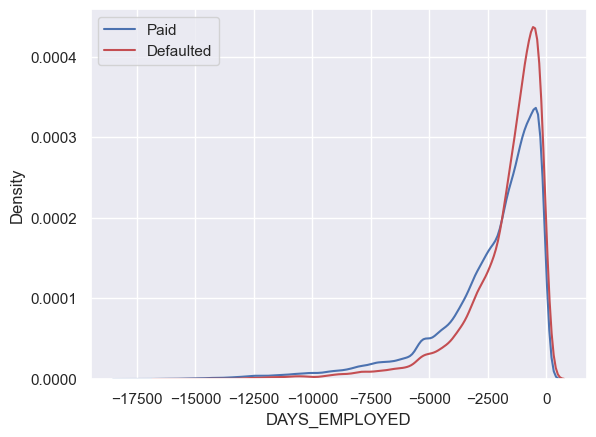

In [29]:
numerical_frame.replace({'DAYS_EMPLOYED': {365243: np.nan}}, inplace=True)
plot_kde_vs_target('DAYS_EMPLOYED', numerical_frame.loc[numerical_frame['DAYS_EMPLOYED']<=0, :])

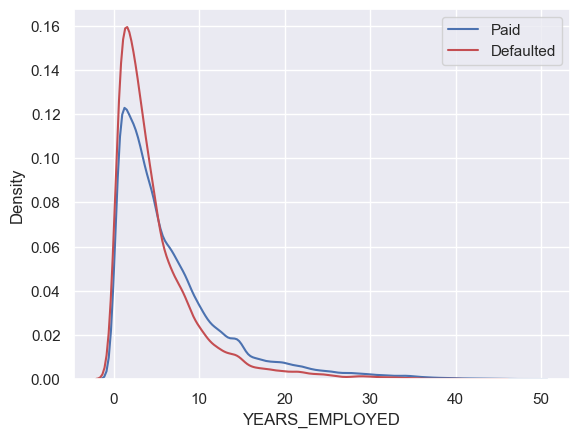

In [30]:
numerical_frame['YEARS_EMPLOYED']=numerical_frame['DAYS_EMPLOYED']/-365
plot_kde_vs_target('YEARS_EMPLOYED', numerical_frame)

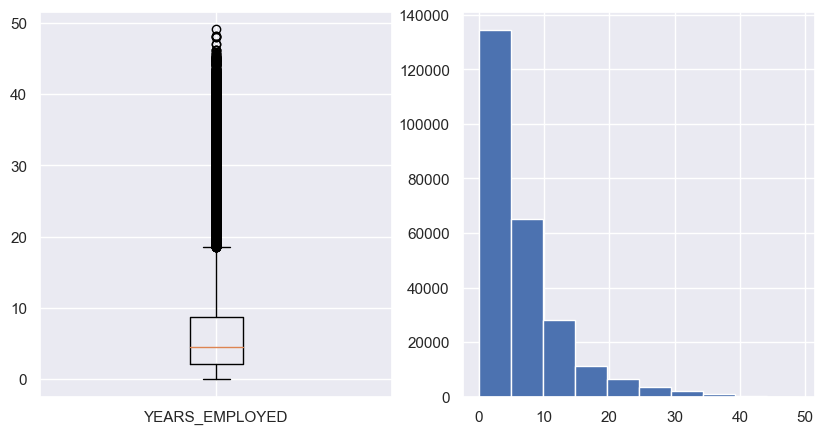

In [31]:
plot_hist_box(numerical_frame, 'YEARS_EMPLOYED')

(-0.001, 1.003]     10.975697
(1.003, 1.879]      11.456996
(1.879, 2.808]      10.972729
(2.808, 3.89]       10.115246
(3.89, 5.208]        9.103871
(5.208, 7.036]       7.757203
(7.036, 9.427]       7.010530
(9.427, 14.008]      5.878993
(14.008, 49.074]     4.663619
Name: YEARS_EMPLOYED_binned, dtype: float64


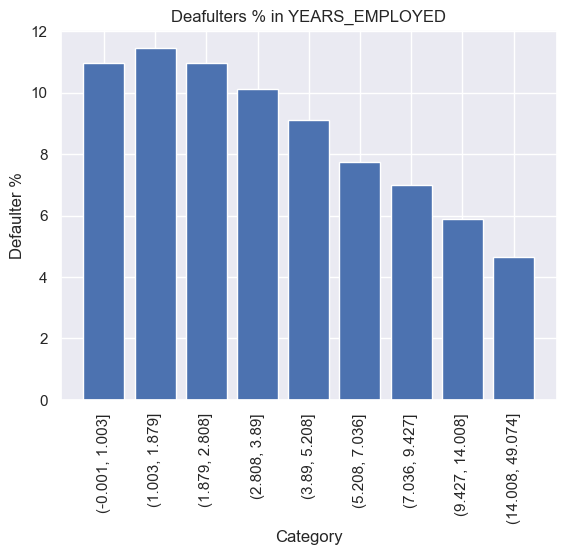

In [32]:
plot_hist_default_pct('YEARS_EMPLOYED', numerical_frame, 9)

#### Looking at outliers

         AMT_CREDIT   YEARS_BIRTH        TARGET
count  5.537400e+04  55374.000000  55374.000000
mean   5.426899e+05     59.753450      0.053996
std    3.784991e+05      5.501600      0.226013
min    4.500000e+04     21.071233      0.000000
25%    2.547000e+05     57.093151      0.000000
50%    4.578345e+05     60.413699      0.000000
75%    7.551900e+05     63.487671      0.000000
max    3.312162e+06     69.120548      1.000000


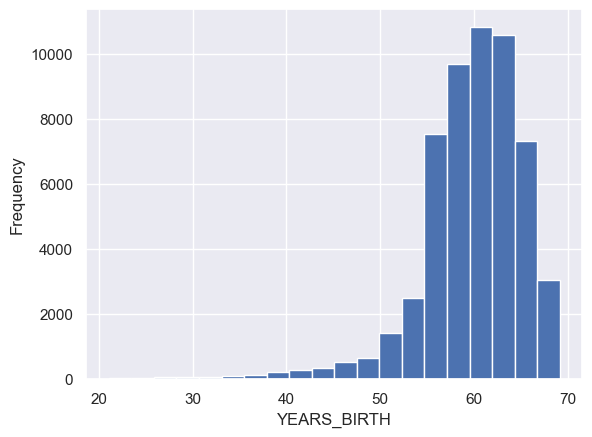

In [33]:
outlier_frame=numerical_frame.loc[numerical_frame['YEARS_EMPLOYED'].isnull(), ['AMT_CREDIT', 'YEARS_BIRTH', 'TARGET']]
print(outlier_frame.describe())
ax=outlier_frame['YEARS_BIRTH'].plot.hist(bins=20)
ax.set_xlabel('YEARS_BIRTH');

In [34]:
mean=numerical_frame.loc[(numerical_frame['YEARS_EMPLOYED']>7.5) & (numerical_frame['YEARS_EMPLOYED']<50), 'YEARS_EMPLOYED'].median()
mean

11.791780821917808

(-0.001, 1.0]       10.971339
(1.0, 1.874]        11.469367
(1.874, 2.803]      10.960913
(2.803, 3.879]      10.142750
(3.879, 5.192]       9.088960
(5.192, 7.011]       7.802434
(7.011, 9.375]       7.027530
(9.375, 11.792]      5.548320
(11.792, 14.022]     5.619109
(14.022, 49.074]     4.661729
Name: YEARS_EMPLOYED_binned, dtype: float64


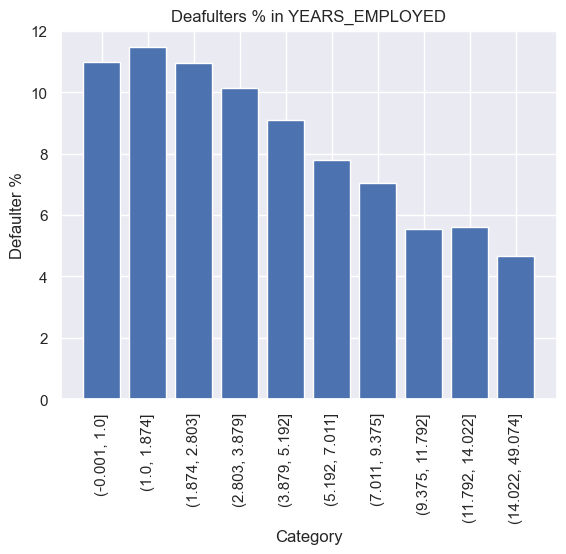

In [35]:
numerical_frame.loc[numerical_frame['YEARS_EMPLOYED'].isnull(), 'YEARS_EMPLOYED']=mean
plot_hist_default_pct('YEARS_EMPLOYED', numerical_frame, 11)

## DAYS_LAST_PHONE_CHANGE

In [57]:
numerical_frame['DAYS_LAST_PHONE_CHANGE'].isnull().sum()

1

In [58]:
numerical_frame['DAYS_LAST_PHONE_CHANGE'].describe()

count    307510.000000
mean       -962.858788
std         826.808487
min       -4292.000000
25%       -1570.000000
50%        -757.000000
75%        -274.000000
max           0.000000
Name: DAYS_LAST_PHONE_CHANGE, dtype: float64

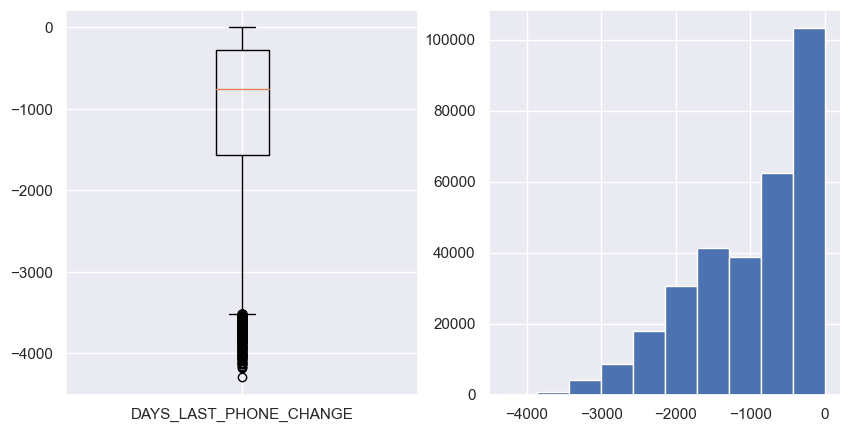

In [59]:
plot_hist_box(numerical_frame, 'DAYS_LAST_PHONE_CHANGE')

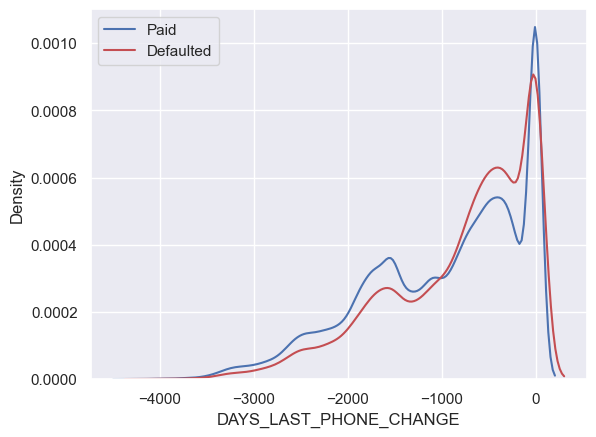

In [60]:
plot_kde_vs_target('DAYS_LAST_PHONE_CHANGE', numerical_frame)

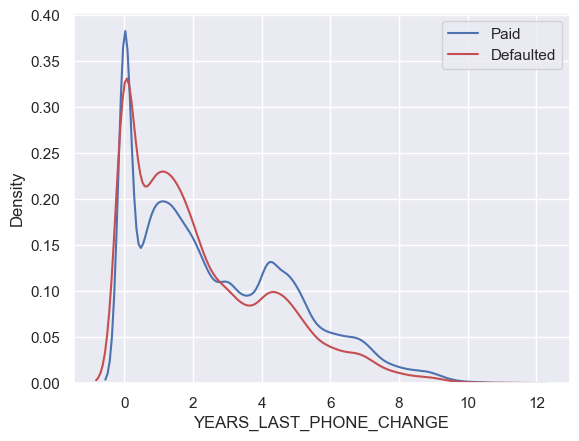

In [63]:
numerical_frame['YEARS_LAST_PHONE_CHANGE']=numerical_frame['DAYS_LAST_PHONE_CHANGE']/-365
plot_kde_vs_target('YEARS_LAST_PHONE_CHANGE', numerical_frame)

(-0.001, 0.592]    9.447335
(0.592, 1.164]     9.585872
(1.164, 1.74]      9.466710
(1.74, 2.488]      8.822155
(2.488, 3.548]     7.624711
(3.548, 4.523]     6.531868
(4.523, 5.712]     6.268840
(5.712, 11.759]    5.456674
Name: YEARS_LAST_PHONE_CHANGE_binned, dtype: float64


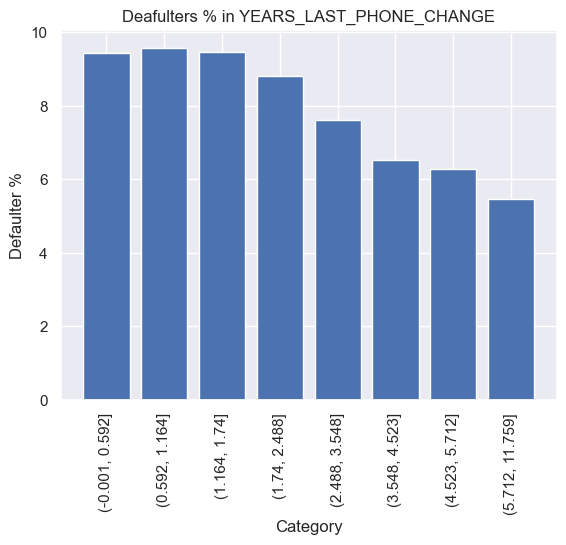

In [64]:
plot_hist_default_pct('YEARS_LAST_PHONE_CHANGE', numerical_frame, 9)

#### Imputing NAN values

In [65]:
numerical_frame.loc[numerical_frame['YEARS_LAST_PHONE_CHANGE'].isnull(), 'TARGET']

15709    0
Name: TARGET, dtype: int64

In [67]:
median=numerical_frame.loc[numerical_frame['TARGET']==0, 'YEARS_LAST_PHONE_CHANGE'].median()
median

2.126027397260274

In [68]:
numerical_frame.loc[numerical_frame['YEARS_LAST_PHONE_CHANGE'].isnull(), 'YEARS_LAST_PHONE_CHANGE']=median